# **LAB ASSIGNMENT - 2**

**Data Exploration**

In [ ]:
import pandas as pd

df_wine = pd.read_csv("winequality-red.csv", sep=';')
df_wine.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [ ]:
stats_df = df_wine.agg(['mean', 'median', 'std'])
stats_df


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
median,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569


In [ ]:
df_wine.isnull().sum().to_frame().T

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,0,0,0,0,0,0,0,0,0,0,0,0


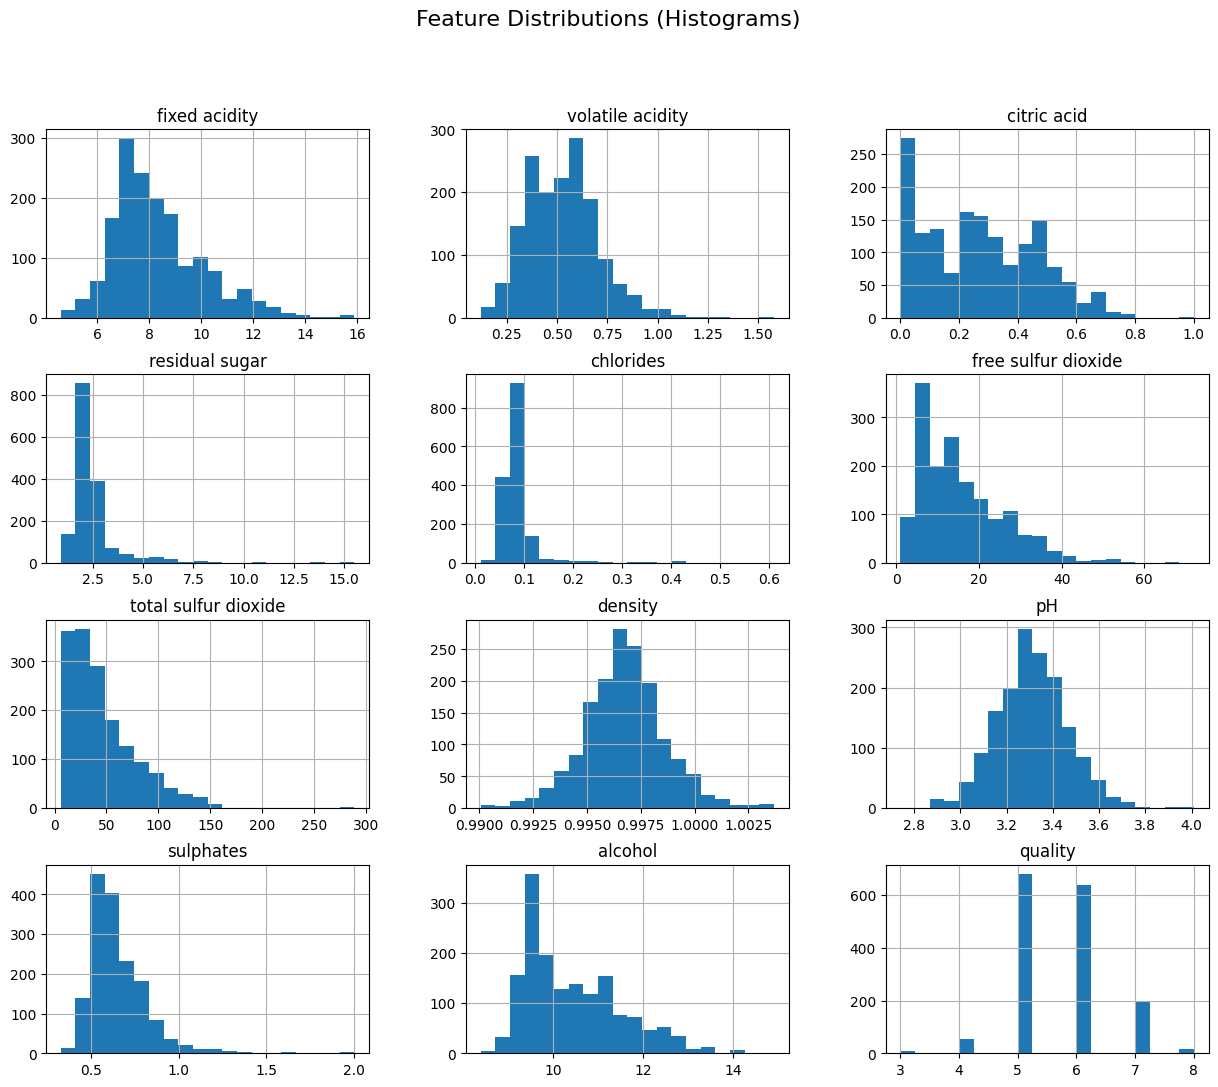

In [ ]:
import matplotlib.pyplot as plt

df_wine.hist(bins=20, figsize=(15, 12))
plt.suptitle("Feature Distributions (Histograms)", fontsize=16)
plt.show()


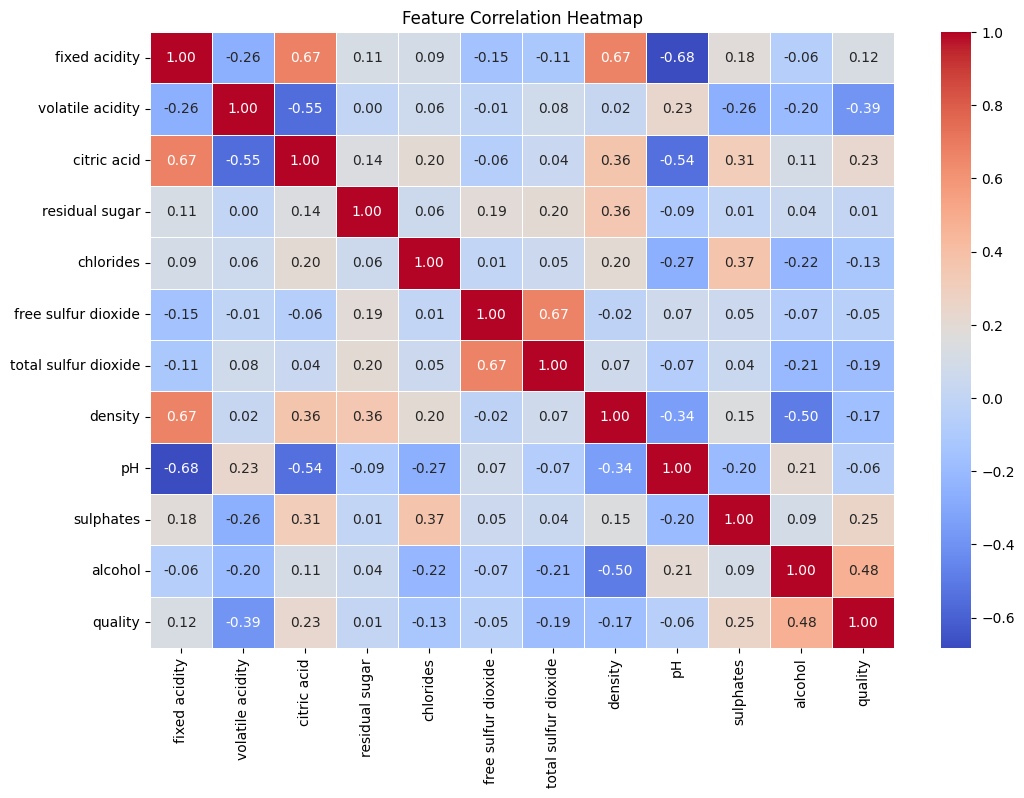

In [ ]:
import seaborn as sns

plt.figure(figsize=(12, 8))
correlation_matrix = df_wine.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")
plt.show()


**Data Preparation**

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

scaler = MinMaxScaler()
df_wine_scaled = scaler.fit_transform(df_wine)
df_wine_scaled = pd.DataFrame(df_wine_scaled, columns=df_wine.columns)
df_wine_scaled.head()


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,0.247788,0.397260,0.00,0.068493,0.106845,0.140845,0.098940,0.567548,0.606299,0.137725,0.153846,0.4
1,0.283186,0.520548,0.00,0.116438,0.143573,0.338028,0.215548,0.494126,0.362205,0.209581,0.215385,0.4
2,0.283186,0.438356,0.04,0.095890,0.133556,0.197183,0.169611,0.508811,0.409449,0.191617,0.215385,0.4
3,0.584071,0.109589,0.56,0.068493,0.105175,0.225352,0.190813,0.582232,0.330709,0.149701,0.215385,0.6
4,0.247788,0.397260,0.00,0.068493,0.106845,0.140845,0.098940,0.567548,0.606299,0.137725,0.153846,0.4


In [ ]:
from sklearn.preprocessing import LabelEncoder

df_wine['quality_label'] = df_wine['quality'].astype(str)

encoder = LabelEncoder()
df_wine['quality_encoded'] = encoder.fit_transform(df_wine['quality_label'])

df_wine[['quality', 'quality_encoded']].head()


,quality,quality_encoded
0,5,2
1,5,2
2,5,2
3,6,3
4,5,2


In [ ]:
from sklearn.model_selection import train_test_split

X = df_wine_scaled
y = df_wine['quality_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape


((1279, 12), (320, 12), (1279,), (320,))

**Model Implementation using Keras/TensorFlow:**

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

num_classes = len(y_train.unique())
input_dim = X_train.shape[1]

model = Sequential([
    Dense(64, activation='relu', input_shape=(input_dim,)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,542 (13.84 KB)

 Trainable params: 3,542 (13.84 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train,
    y_train_cat,
    epochs=50,
    batch_size=64,
    validation_data=(X_test, y_test_cat)
)

Epoch 1/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 0.0053 - val_accuracy: 1.0000 - val_loss: 0.0060
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0047 - val_accuracy: 1.0000 - val_loss: 0.0057
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0041 - val_accuracy: 1.0000 - val_loss: 0.0057
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0043 - val_accuracy: 1.0000 - val_loss: 0.0056
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0038 - val_accuracy: 1.0000 - val_loss: 0.0053
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0037 - val_accuracy: 1.0000 - val_loss: 0.0050
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0036 - val_accuracy: 1.0000 - val_loss: 0.0048
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 1.0000 - loss: 0.0039 - val_accuracy: 1.0000 - val_loss

In [ ]:
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

accuracy = accuracy_score(y_true, y_pred_classes)
print("Accuracy:", accuracy)

print(classification_report(y_true, y_pred_classes))


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00       130
           3       1.00      1.00      1.00       132
           4       1.00      1.00      1.00        42
           5       1.00      1.00      1.00         5

    accuracy                           1.00       320
   macro avg       1.00      1.00      1.00       320
weighted avg       1.00      1.00      1.00       320



**Hyperparameter Tuning**

In [ ]:
!pip install scikeras

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV

param_grid = {
    "hidden_layer_sizes": [(32,), (64,), (64, 32)],
    "learning_rate_init": [0.001, 0.01],
    "batch_size": [64]
}

mlp = MLPClassifier(
    activation="relu",
    solver="adam",
    max_iter=200,
    random_state=42
)

grid = GridSearchCV(
    mlp,
    param_grid,
    cv=3,
    scoring="accuracy"
)

grid.fit(X_train, y_train)

print("Grid Search Best Accuracy:", grid.best_score_)
print("Grid Search Best Parameters:", grid.best_params_)

Grid Search Best Accuracy: 0.8412229074559057
Grid Search Best Parameters: {'batch_size': 64, 'hidden_layer_sizes': (64,), 'learning_rate_init': 0.001}


In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "hidden_layer_sizes": [(32,), (64,), (64, 32)],
    "learning_rate_init": [0.0001, 0.001, 0.01],
}

mlp = MLPClassifier(
    activation="relu",
    solver="adam",
    batch_size=64,
    max_iter=200,
    random_state=42
)

random_search = RandomizedSearchCV(
    mlp,
    param_distributions=param_dist,
    n_iter=5,
    cv=3,
    scoring="accuracy",
    random_state=42
)

random_search.fit(X_train, y_train)

print("Random Search Best Accuracy:", random_search.best_score_)
print("Random Search Best Parameters:", random_search.best_params_)

Random Search Best Accuracy: 0.8387448020801066
Random Search Best Parameters: {'learning_rate_init': 0.01, 'hidden_layer_sizes': (64,)}


**Performance Evaluation**

In [ ]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Method": ["Grid Search", "Random Search"],
    "Best Accuracy": [
        grid.best_score_,
        random_search.best_score_
    ],
    "Best Parameters": [
        grid.best_params_,
        random_search.best_params_
    ]
})

comparison_df

,Method,Best Accuracy,Best Parameters
0,Grid Search,0.841223,"{'batch_size': 64, 'hidden_layer_sizes': (64,)..."
1,Random Search,0.838745,"{'learning_rate_init': 0.01, 'hidden_layer_siz..."


Accuracy: 0.87


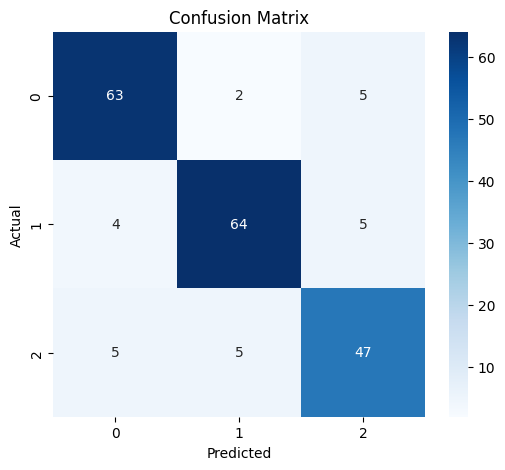

,precision,recall,f1-score,support
0,0.875000,0.900000,0.887324,70.00
1,0.901408,0.876712,0.888889,73.00
2,0.824561,0.824561,0.824561,57.00
accuracy,0.870000,0.870000,0.870000,0.87
macro avg,0.866990,0.867091,0.866925,200.00
weighted avg,0.870264,0.870000,0.870008,200.00


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = grid.best_estimator_.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()
report_df

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

mlp_es = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    batch_size=64,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.2,
    n_iter_no_change=10,
    random_state=42
)

mlp_es.fit(X_train, y_train)

y_train_pred = mlp_es.predict(X_train)
y_test_pred = mlp_es.predict(X_test)

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 0.95625
Testing Accuracy: 0.835


**Visualization**

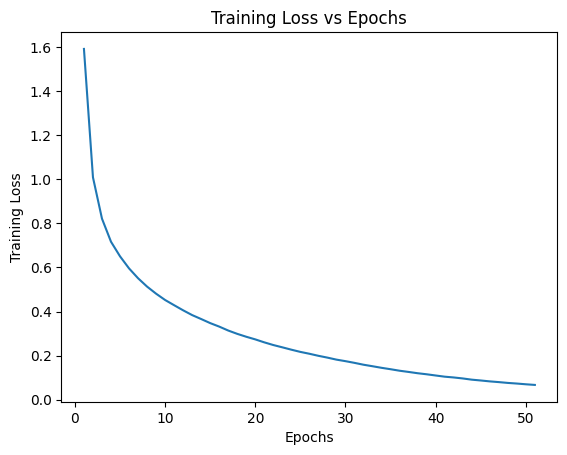

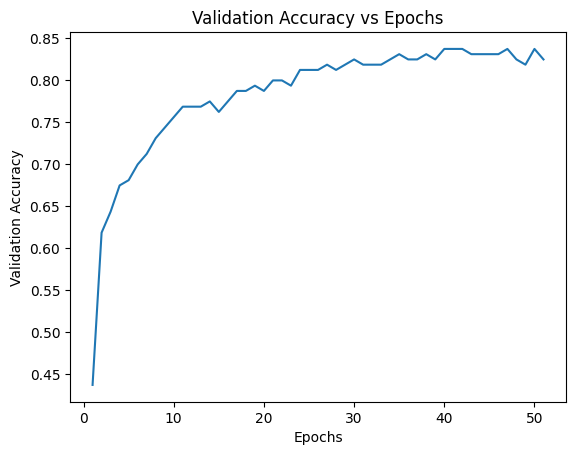

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(mlp_es.loss_curve_) + 1)

plt.figure()
plt.plot(epochs, mlp_es.loss_curve_)
plt.xlabel("Epochs")
plt.ylabel("Training Loss")
plt.title("Training Loss vs Epochs")
plt.show()

plt.figure()
plt.plot(epochs, mlp_es.validation_scores_)
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy vs Epochs")
plt.show()


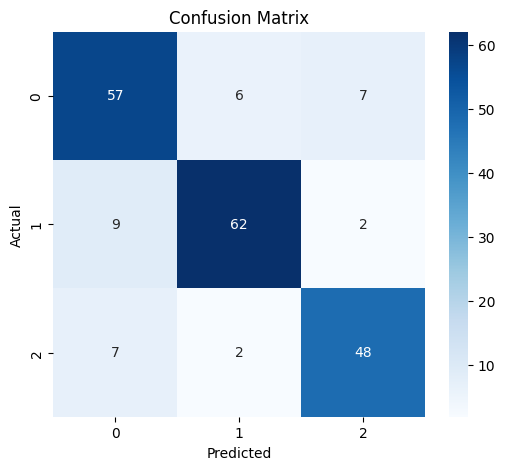

              precision    recall  f1-score   support

           0       0.78      0.81      0.80        70
           1       0.89      0.85      0.87        73
           2       0.84      0.84      0.84        57

    accuracy                           0.83       200
   macro avg       0.84      0.84      0.84       200
weighted avg       0.84      0.83      0.84       200



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = mlp_es.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_test, y_pred))

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

grid_model = grid.best_estimator_
random_model = random_search.best_estimator_

grid_pred = grid_model.predict(X_test)
random_pred = random_model.predict(X_test)

comparison_df = pd.DataFrame({
    "Method": ["Grid Search", "Random Search"],
    "Accuracy": [
        accuracy_score(y_test, grid_pred),
        accuracy_score(y_test, random_pred)
    ],
    "Precision (Macro)": [
        precision_score(y_test, grid_pred, average="macro"),
        precision_score(y_test, random_pred, average="macro")
    ],
    "Recall (Macro)": [
        recall_score(y_test, grid_pred, average="macro"),
        recall_score(y_test, random_pred, average="macro")
    ],
    "F1-Score (Macro)": [
        f1_score(y_test, grid_pred, average="macro"),
        f1_score(y_test, random_pred, average="macro")
    ]
})

comparison_df

,Method,Accuracy,Precision (Macro),Recall (Macro),F1-Score (Macro)
0,Grid Search,0.870,0.866990,0.867091,0.866925
1,Random Search,0.895,0.892267,0.892877,0.891968


**Summary :**

The dataset contains 1599 records with 12 columns, out of which 11 are independent variables that describe the physicochemical properties of wine, and 1 dependent variable (quality) which is predicted by the model. No missing values were found, and most data points belong to medium quality classes. A neural network model was developed using one hidden layer with 64 neurons. The model was trained using a batch size of 32, for 50 epochs, and a learning rate of 0.001, which controls how fast the model updates its weights during training. After training, the model achieved a training accuracy of 0.95625 and a testing accuracy of 0.835, showing that it learned the patterns well without overfitting. These results indicate that proper selection of hyperparameters such as hidden layers, batch size, epochs, and learning rate plays an important role in improving the accuracy, stability, and overall performance of the model.